In [1]:
import pandas as pd
import numpy as np
import os
np.random.seed(0)  # for reproducibility
# ------------------------------------------------------------------
# 1. Load CSV and inspect
# ------------------------------------------------------------------
csv_root = r"C:\Users\espen\Documents\work\PhD\papers\4_ICIP_salmon_reid\data\statistical"
csv_files = os.listdir(csv_root)

B = 50000  # number of bootstrap samples
rng = np.random.default_rng(seed=0)
model_files = {
    "baseline_ViT": "ap_per_query_ViT.csv",
    "ConvNeXt": "ap_per_query_convnext.csv",
    "Q1_single": "ap_per_query_Q1_single.csv",
    "Q2_single": "ap_per_query_Q2_single.csv",
    "Q1_sliced": "ap_per_query_Q1_sliced.csv",
    "Q2_sliced": "ap_per_query_Q2_sliced.csv",
    "head": "ap_per_query_head.csv",
    "dorsal_fin": "ap_per_query_dorsal_fin.csv",
    "ensemble_single": "ap_per_query_ensemble_single.csv",
    "ensemble_sliced": "ap_per_query_ensemble_sliced.csv",
}

In [2]:
# Plot single model bootstrap results
rows = []
for name, file in model_files.items():
    csv_path = os.path.join(csv_root, file)
    df = pd.read_csv(csv_path)

    ap = df["AP"].values
    n = len(ap)

    mAP = ap.mean()

    boot_means = np.empty(B, dtype=float)

    for b in range(B):
        # sample indices with replacement from 0..n-1
        sample_idx = rng.integers(low=0, high=n, size=n)
        boot_sample = ap[sample_idx]
        boot_means[b] = boot_sample.mean()

    # 95% percentile CI
    lower = round(np.percentile(boot_means, 2.5), 3)
    upper = round(np.percentile(boot_means, 97.5), 3)

    rows.append({
        "Model": name,
        "mAP": mAP,
        "CI95_low": lower,
        "CI95_up": upper,
    })

results_df = pd.DataFrame(rows)

print("\n======= Single model bootstrap results ==============")
print(results_df[['Model','mAP','CI95_low','CI95_up']]
    .to_string(index=False, float_format="{:.3f}".format))




======= Single model bootstrap results ==============
          Model   mAP  CI95_low  CI95_up
   baseline_ViT 0.609     0.537    0.679
       ConvNeXt 0.270     0.210    0.333
      Q1_single 0.378     0.308    0.450
      Q2_single 0.718     0.652    0.781
      Q1_sliced 0.573     0.493    0.652
      Q2_sliced 0.755     0.684    0.820
           head 0.517     0.435    0.599
     dorsal_fin 0.531     0.464    0.599
ensemble_single 0.798     0.739    0.854
ensemble_sliced 0.860     0.810    0.906


In [3]:
# Load AP vectors
aps = {}
for name, file in model_files.items():
    path = os.path.join(csv_root, file)
    df = pd.read_csv(path)
    aps[name] = df["AP"].values

# Check all lengths are equal (same query set)
print("\n======= Model pairwise bootstrap results ==============")
lengths = {name: len(v) for name, v in aps.items()}
print('Lengths: ', lengths)

model_names = list(aps.keys())
M = len(model_names)
n = len(aps[model_names[0]])

# Matrices: diff_ij = mAP(model_i) - mAP(model_j)
diff_matrix = np.zeros((M, M), dtype=float)
pval_matrix = np.ones((M, M), dtype=float)

rows = []
for i, mi in enumerate(model_names):
    ap_i = aps[mi]
    ap_i_centered = ap_i - ap_i.mean()  # center to mean for bootstrap
    mAP_i = ap_i.mean()

    # Only iterate over upper triangle (j > i) to avoid redundant calculations
    for j, mj in enumerate(model_names):
        if j < i:
            continue
        elif j == i:
            pval_matrix[i, j] = 1.0
            continue

        ap_j = aps[mj]
        ap_j_centered = ap_j - ap_j.mean()  # center to mean for bootstrap
        mAP_j = ap_j.mean()

        diff_emp = mAP_i - mAP_j
        diff_matrix[i, j] = diff_emp

        # Bootstrap differences
        boot_diffs = np.empty(B, dtype=float)
        for b in range(B):
            idx = rng.integers(low=0, high=n, size=n)
            boot_diffs[b] = ap_i_centered[idx].mean() - ap_j_centered[idx].mean()

        # Two-sided bootstrap p-value for H0
        p_val = (np.sum(np.abs(boot_diffs) >= abs(diff_emp)) / B)
        pval_matrix[i, j] = p_val

        rows.append({
            "Model_i": mi,
            "Model_j": mj,
            "delta_mAP": diff_emp,
            "p": p_val,
        })



======= Model pairwise bootstrap results ==============
Lengths:  {'baseline_ViT': 85, 'ConvNeXt': 85, 'Q1_single': 85, 'Q2_single': 85, 'Q1_sliced': 85, 'Q2_sliced': 85, 'head': 85, 'dorsal_fin': 85, 'ensemble_single': 85, 'ensemble_sliced': 85}


In [4]:
results_df = pd.DataFrame(rows)
print(results_df[['Model_i', 'Model_j', 'delta_mAP', 'p']]
    .to_string(index=False, float_format="{:.4f}".format))

        Model_i         Model_j  delta_mAP      p
   baseline_ViT        ConvNeXt     0.3396 0.0000
   baseline_ViT       Q1_single     0.2311 0.0000
   baseline_ViT       Q2_single    -0.1089 0.0104
   baseline_ViT       Q1_sliced     0.0364 0.4360
   baseline_ViT       Q2_sliced    -0.1457 0.0011
   baseline_ViT            head     0.0919 0.0427
   baseline_ViT      dorsal_fin     0.0780 0.0469
   baseline_ViT ensemble_single    -0.1885 0.0000
   baseline_ViT ensemble_sliced    -0.2511 0.0000
       ConvNeXt       Q1_single    -0.1085 0.0053
       ConvNeXt       Q2_single    -0.4485 0.0000
       ConvNeXt       Q1_sliced    -0.3032 0.0000
       ConvNeXt       Q2_sliced    -0.4853 0.0000
       ConvNeXt            head    -0.2477 0.0000
       ConvNeXt      dorsal_fin    -0.2616 0.0000
       ConvNeXt ensemble_single    -0.5281 0.0000
       ConvNeXt ensemble_sliced    -0.5907 0.0000
      Q1_single       Q2_single    -0.3400 0.0000
      Q1_single       Q1_sliced    -0.1947 0.0000


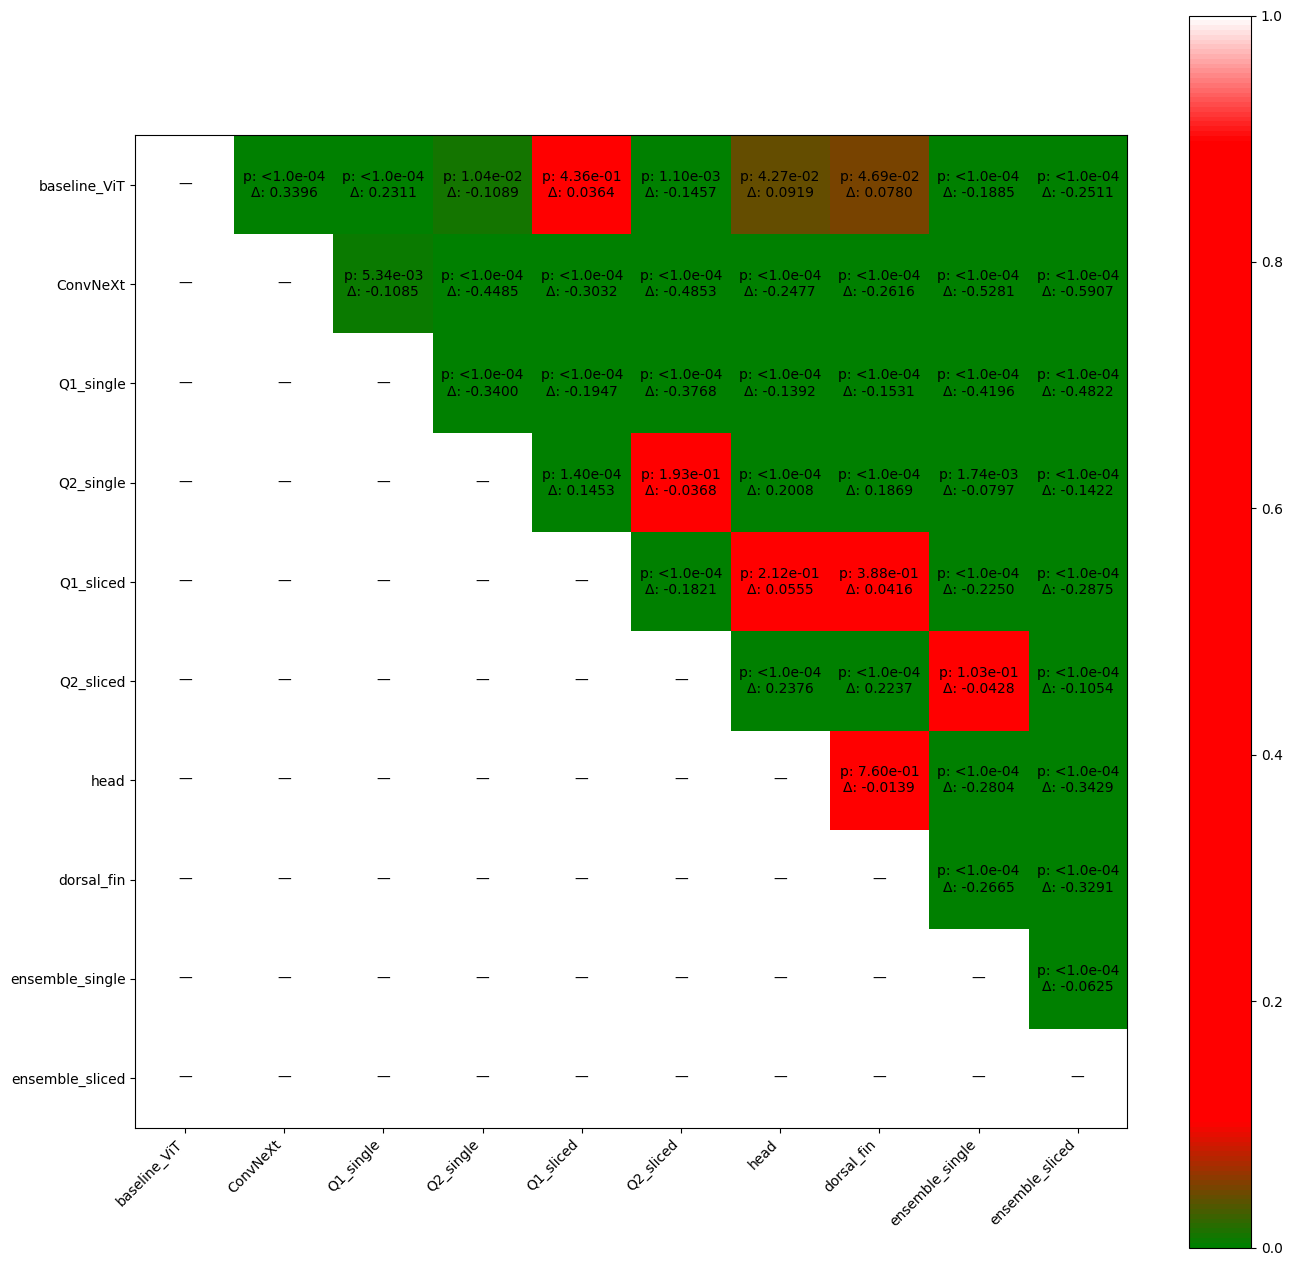

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

M = len(model_names)

# Custom colormap: green (−1) → white (0) → blue (+1)
colors = [
    (0.0, "green"),  # at -1
    (0.1, "red"),   # at +1
    (0.9, "red"),
    (1.0, "white"),   # at +1
]
cmap_custom = LinearSegmentedColormap.from_list("GreenWhiteBlue", colors)

fig, ax = plt.subplots(figsize=(16, 16))

im = ax.imshow(pval_matrix, cmap=cmap_custom, vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax)
ax.set_xticks(range(M))
ax.set_yticks(range(M))
ax.set_xticklabels(model_names, rotation=45, ha="right")
ax.set_yticklabels(model_names)

# Annotate each cell with p-value
for i in range(M):
    for j in range(M):
        p = pval_matrix[i, j]
        diff = diff_matrix[i, j]
        if i >= j:
            text = "—"
        else:
            if p < 1.0e-04:
                text = "p: <1.0e-04\n"
            else:
                text = f"p: {p:.2e}\n"
            text += f"Δ: {diff:.4f}"

        ax.text(
            j, i, text,
            ha="center", va="center",
            color='black', fontsize=10
        )

